# Examinando a Variável de Resposta e Concluindo a Exploração Inicial

Uma conta ficará inadimplente no próximo mês ou não?
- `default payment next month` = 1 -> Classe Positiva
- `default payment next month` = 0 -> Classe Negativa

Qual é a proporção da Classe Positiva?

In [1]:
import numpy as np  #cálculo numérico
import pandas as pd  #preparação dos dados
import matplotlib.pyplot as plt  #pacote de plotagem

#ajuda a renderizar plotagens
%matplotlib inline
import matplotlib as mpl  #adiciona funcionalidade de plotagem

mpl.rcParams['figure.dpi'] = 400  #figuras em alta resolução

In [2]:
df = pd.read_csv(
    '/Users/danniells/Downloads/Projetos DS/Livro_Projeto_Python/Capitulo_1/data-cleaning-credit-case/Capitulo_1_limpando_dados.csv')

In [22]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month', 'EDUCATION_CAT', 'graduate school',
       'high school', 'others', 'university'],
      dtype='object')

In [23]:
df['default payment next month'].mean()  #calcula a média da variável de resposta no dataset inteiro

np.float64(0.2217971797179718)

In [24]:
df.groupby('default payment next month')['ID'].count()  #verifica o número de contas em cada classe

default payment next month
0    20750
1     5914
Name: ID, dtype: int64

## Regressão Logística

In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
lr.C = 0.1
lr.solver = 'liblinear'
lr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [27]:
X = df['EDUCATION'][0:10].values.reshape(-1,
                                         1)  #pega as 10 primeiras amostras de uma caracteristica(coluna) e usa o reshape para redimensionar as colunas
X

array([[2],
       [2],
       [2],
       [2],
       [2],
       [1],
       [1],
       [2],
       [3],
       [3]])

In [28]:
y = df['default payment next month'][0:10].values  #pega os 10 primeiros valores da variável de resposta
y

array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [29]:
lr.fit(X, y)  #ajusta a regressão logística com os dados, sendo assim, um modelo treinado

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [30]:
novo_X = df['EDUCATION'][10:20].values.reshape(-1, 1)
novo_X

array([[3],
       [1],
       [2],
       [2],
       [1],
       [3],
       [1],
       [1],
       [1],
       [3]])

In [31]:
lr.predict(novo_X)  #realiza a previsão com base no que foi treinado, sem saber o valor verdadeiro, no caso, o y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [32]:
df['default payment next month'][10:20].values  #mostra os valores reais

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0])

In [33]:
np.random.seed(seed=1)
X = np.random.uniform(low=0.0, high=10.0, size=(1000,))
X[0:10]

array([4.17022005e+00, 7.20324493e+00, 1.14374817e-03, 3.02332573e+00,
       1.46755891e+00, 9.23385948e-01, 1.86260211e+00, 3.45560727e+00,
       3.96767474e+00, 5.38816734e+00])

## Dados para Regressão Linear
- Array de 1000 pontos de dados com a mesma dimensão (size) do array de caracteristica X
- Média do ruído (loc) é 0
- Desvio padrão (scale) é 1

Fórmula: $$ y = a_x + b + N(u,o)
$$

- a -> inclinação
- b -> interceptação
- Ruído Gaussiano tem média = u
- Com Desvio Padrão em o
- y -> vetor de respostas
- x -> array de características

In [34]:
np.random.seed(seed=1)
slope = 0.25
intercept = -1.25
y = slope * X + np.random.normal(loc=0, scale=1, size=(1000,)) + intercept

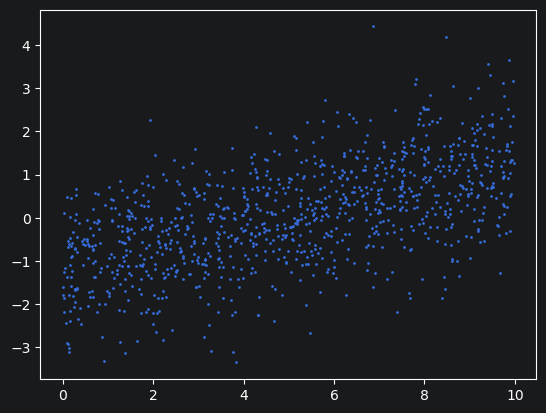

In [35]:
mpl.rcParams['figure.dpi'] = 100
plt.scatter(X,y,s=1)

## Exercício 8
- pegaremos os dados sintéticos que acabamos de gerar e determinaremos uma linha de melhor ajuste, ou regressão linear, usando o scikit-learn.

In [36]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
#ajusta o modelo, .intercep tem a interceptação do modelo ajustado, .coef contém a inclinação
lin_reg.fit(X.reshape(-1,1), y)
print(lin_reg.intercept_)
print(lin_reg.coef_)

-1.1612566002825881
[0.24002588]


In [42]:
y_pred = lin_reg.predict(X.reshape(-1,1))

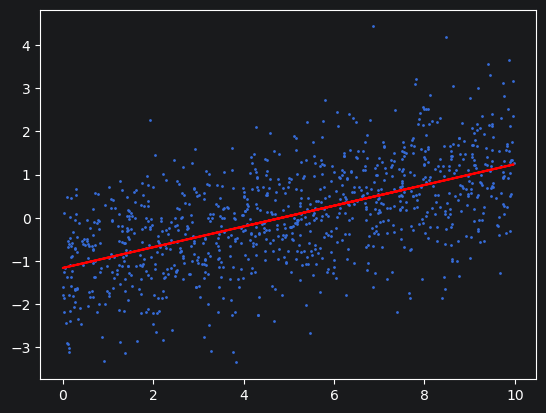

In [43]:
plt.scatter(X,y,s=1)
plt.plot(X,y_pred,'r')